# Báo cáo: Xây dựng và Triển khai thuật toán Logistic Regression

## 1. Giới thiệu mô hình
Logistic Regression được sử dụng chủ yếu cho các bài toán phân lớp nhị phân (Binary Classification). Đầu ra của mô hình được đưa qua hàm Sigmoid để giới hạn giá trị trong khoảng $(0, 1)$, đại diện cho xác suất xảy ra của một sự kiện.

Hàm Sigmoid (Activation function):
$$\sigma(z) = \frac{1}{1 + e^{-z}}$$


Mô hình dự đoán đầu ra $\hat{y}$ với đầu vào $X$ và trọng số $w$:
$$\hat{y}_i = \sigma(w_0 + w_1 x_{1}^{(i)} + w_2 x_{2}^{(i)})$$

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Định nghĩa hàm Sigmoid
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Tập dữ liệu (x1: Mức lương, x2: Kinh nghiệm)
x = np.array([[10, 1], [9, 0.5], [5, 2], [8, 0.1], [6, 0.3], [7, 0.15]])

# Nhãn thực tế (1: Cho vay, 0: Từ chối)
y = np.array([[1], [1], [1], [0], [0], [0]])

N = x.shape[0] # Số lượng mẫu dữ liệu

# Thêm cột toàn số 1 vào ma trận X để tính hệ số tự do w0 (bias)
x_bar = np.hstack((np.ones((N, 1)), x))

# Khởi tạo ma trận trọng số w ban đầu (w0, w1, w2)
w = np.array([0., 0.1, 0.1]).reshape(-1, 1)

## 2. Hàm mất mát và Tối ưu hóa bằng Gradient Descent

Thay vì sử dụng MSE, Logistic Regression sử dụng hàm **Binary Cross-Entropy** để đánh giá sai số giữa dự đoán $\hat{y}$ và nhãn thực tế $y$. Hàm này phạt rất nặng khi mô hình dự đoán sai với độ tự tin cao.

Công thức hàm mất mát cho toàn bộ dữ liệu:
$$J = -\frac{1}{N}\sum_{i=1}^N \left( y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i) \right)$$

Để tìm bộ trọng số $w$ tối ưu, ta áp dụng quy tắc chuỗi (Chain Rule) để tính đạo hàm của hàm mất mát:
$$\frac{\partial J}{\partial w} = X^T (\hat{y} - y)$$

Công thức cập nhật trọng số trong thuật toán Gradient Descent:
$$w = w - \eta X^T (\hat{y} - y)$$

In [10]:
numOfIteration = 1000  # Số vòng lặp
learning_rate = 0.01   # Hệ số học (eta)
cost = np.zeros((numOfIteration, 1)) # Mảng lưu giá trị hàm mất mát

for i in range(1, numOfIteration):
    # Tính dự đoán của mô hình
    y_predict = sigmoid(np.dot(x_bar, w))
    
    # Tính trung bình hàm mất mát Cross-Entropy
    cost[i] = -np.sum(np.multiply(y, np.log(y_predict)) + np.multiply(1-y, np.log(1-y_predict))) / N
    
    # Tính đạo hàm (Gradient) và cập nhật trọng số w (Gradient Descent)
    w = w - learning_rate * np.dot(x_bar.T, y_predict - y) / N

## 3. Đường phân định (Decision Boundary)

Sau khi tìm được bộ trọng số tối ưu, để phân loại một điểm dữ liệu, ta cần chọn một ngưỡng xác suất $t$ (thường $t = 0.5$).

Đường phân định giữa hai lớp dữ liệu là một đường thẳng có phương trình:
$$w_0 + w_1 x_1 + w_2 x_2 = \ln\left(\frac{1}{t} - 1\right)$$

Nếu $t = 0.5$, phương trình đơn giản thành:
$$w_0 + w_1 x_1 + w_2 x_2 = 0$$

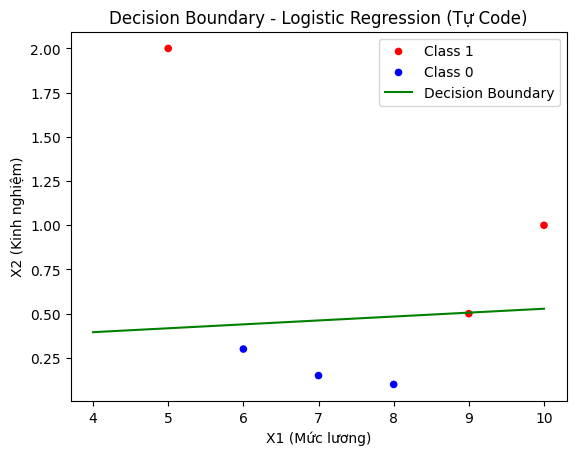

In [11]:
t = 0.5 # Ngưỡng phân loại

# Vẽ các điểm dữ liệu (Class 1 màu đỏ, Class 0 màu xanh)
plt.scatter(x[:3, 0], x[:3, 1], c='red', edgecolors='none', s=30, label='Class 1')
plt.scatter(x[3:, 0], x[3:, 1], c='blue', edgecolors='none', s=30, label='Class 0')

# Vẽ đường thẳng phân định (Decision Boundary) dựa trên phương trình w0 + w1*x1 + w2*x2 = 0
plt.plot((4, 10), (-(w[0] + 4*w[1] + np.log(1/t-1))/w[2], -(w[0] + 10*w[1] + np.log(1/t-1))/w[2]), 'g', label='Decision Boundary')

plt.xlabel('X1 (Mức lương)')
plt.ylabel('X2 (Kinh nghiệm)')
plt.title('Decision Boundary - Logistic Regression (Tự Code)')
plt.legend()
plt.show()

## 4. Triển khai bằng Thư viện Scikit-Learn

Ta có thể đối chiếu kết quả tự code ở trên với bộ thư viện `LogisticRegression` của Scikit-Learn.

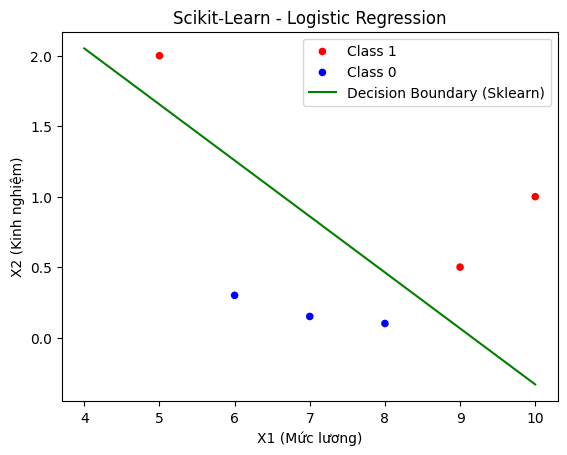

In [12]:
from sklearn.linear_model import LogisticRegression

# Khởi tạo và huấn luyện mô hình bằng thư viện
logreg = LogisticRegression()
logreg.fit(x, y.ravel())

# Lấy trọng số w từ mô hình thư viện
wg = np.zeros((3, 1))
wg[0, 0] = logreg.intercept_[0]      # Trọng số w0 (bias)
wg[1:, 0] = logreg.coef_[0]          # Trọng số w1, w2

# Vẽ đồ thị so sánh kết quả của Scikit-Learn
plt.scatter(x[:3, 0], x[:3, 1], c='red', edgecolors='none', s=30, label='Class 1')
plt.scatter(x[3:, 0], x[3:, 1], c='blue', edgecolors='none', s=30, label='Class 0')

plt.plot((4, 10), (-(wg[0] + 4*wg[1] + np.log(1/t-1))/wg[2], -(wg[0] + 10*wg[1] + np.log(1/t-1))/wg[2]), 'g', label='Decision Boundary (Sklearn)')

plt.xlabel('X1 (Mức lương)')
plt.ylabel('X2 (Kinh nghiệm)')
plt.title('Scikit-Learn - Logistic Regression')
plt.legend()
plt.show()